In [ ]:
# Code created by Pablo Cárdenas R., pablocarderam@gmail.com

In [2]:
!pip install -q --no-warn-conflicts biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.2 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")
sns.set_context("talk")
cbPalette = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#999999"]

import joblib as jl
from Bio import SeqIO

In [5]:
# Utility functions:

"""
Returns the reverse complement of a sequence
"""
def revComp(seq):
    revSeq = seq[::-1]; # reverse seq

    # replace nucleotides, conserve case
    revSeq = revSeq.replace("A", "1");
    revSeq = revSeq.replace("T", "2");
    revSeq = revSeq.replace("G", "3");
    revSeq = revSeq.replace("C", "4");

    revSeq = revSeq.replace("2", "A");
    revSeq = revSeq.replace("1", "T");
    revSeq = revSeq.replace("4", "G");
    revSeq = revSeq.replace("3", "C");

    revSeq = revSeq.replace("a", "1");
    revSeq = revSeq.replace("t", "2");
    revSeq = revSeq.replace("g", "3");
    revSeq = revSeq.replace("c", "4");

    revSeq = revSeq.replace("2", "a");
    revSeq = revSeq.replace("1", "t");
    revSeq = revSeq.replace("4", "g");
    revSeq = revSeq.replace("3", "c");

    return revSeq;

"""
Transcribes DNA to RNA
"""
def transcribe(dna):
    rna = dna.replace("T", "U");
    rna = rna.replace("t", "u");
    return rna;

"""
Returns genetic code dictionary. Stop codons are "*"
"""
def geneticCode():
    code = {'CGA':'R','UUU':'F','UUC':'F',
      'UUA':'L','UUG':'L','UCU':'S',
      'UCC':'S','UCA':'S','UCG':'S',
      'UAU':'Y','UAC':'Y','UAA':'*',
      'UAG':'*','UGU':'C','UGC':'C',
      'UGA':'*','UGG':'W','CUU':'L',
      'CUC':'L','CUA':'L','CUG':'L',
      'CCU':'P','CCC':'P','CCA':'P',
      'CCG':'P','CAU':'H','CAC':'H',
      'CAA':'Q','CAG':'Q','CGU':'R',
      'CGC':'R','AGA':'R','CGG':'R',
      'AUU':'I','AUC':'I','AUA':'I',
      'AUG':'M','ACU':'T','ACC':'T',
      'ACA':'T','ACG':'T','AAU':'N',
      'AAC':'N','AAA':'K','AAG':'K',
      'AGU':'S','AGC':'S','GGA':'G',
      'AGG':'R','GUU':'V','GUC':'V',
      'GUA':'V','GUG':'V','GCU':'A',
      'GCC':'A','GCA':'A','GCG':'A',
      'GAU':'D','GAC':'D','GAA':'E',
      'GAG':'E','GGU':'G','GGC':'G',
      'GGG':'G'
      };
    return code;

"""
Translates RNA to protein (takes rna string, returns peptide string).
"""
def translate(pSeq):
    seq = transcribe(pSeq.upper()); # everything to uppercase
    code = geneticCode(); # Stores genetic code
    pep = ""; # stores peptide sequence
    i = 0; # position on RNA sequence
    while i < len(seq): # for every codon
        codon = seq[i:(i+3)]; # get current codon
        if len(codon) == 3:
            aa = code[codon]; # get aminoacid
            pep = pep + aa; # add residue to peptide
#             if (aa != "*"): # if not a stop codon
            i = i+3; # next codon
#             else: # if codon is stop
#                 i = len(seq); # stop loop
        else:
            i = len(seq); # stop loop
    return pep;

In [4]:
fasta_sequences = SeqIO.parse(open("genbank_proteins_prot.fasta"),'fasta')
seqs = []
ids = []
for fasta in fasta_sequences:
    ids.append(str(fasta.id))
    seqs.append(str(fasta.seq))

fasta_sequences = SeqIO.parse(open("genbank_proteins_nt.fasta"),'fasta')
for fasta in fasta_sequences:
    ids.append(str(fasta.id))
    seqs.append(str(fasta.seq))

len(seqs)

9391

In [37]:
# Now we analyze the numbers and types of repeats

rep_seq = 'NVDP' #'NPNV'
    # the key repeat sequence being studied the minor repeat
    # (actual epitope is NPNV)
threepeat_seq = 'NVDPNANPNVDPNANPNVDP'
    # The most common motif the minor repeat is found in

# We build a dataframe for all the info
dat = pd.DataFrame()
dat['Sample'] = ids
dat['Protein'] = seqs
dat['Num_NANP'] = dat['Protein'].str.count('NANP')
dat['Num_'+rep_seq] = dat['Protein'].str.count(rep_seq)

# Split protein sequences by the repeat sequence
spl = dat['Protein'].str.split(rep_seq)

'''
Minimum distance in aa between repeats when given the list of sequences between
repeats
'''
def minRepeatDist(frags):
    if len(frags) > 2:
        return min( [ len(frag) for frag in frags[1:-1] ] )
    else:
        return np.nan

'''
Mean distance in aa between repeats when given the list of sequences between
repeats
'''
def meanRepeatDist(frags):
    if len(frags) > 2:
        return np.array( [ len(frag) for frag in frags[1:-1] ] ).mean()
    else:
        return np.nan

'''
Number of instances in which two repeats are separated by a specific number of
aa when given the list of sequences between repeats
'''
def numAtDistance(frags,d=4):
    if len(frags) > 2:
        return np.count_nonzero( np.array( [ len(frag) for frag in frags[1:-1] ] ) == d )
    else:
        return np.nan

# Compute values
dat['Min_dist_between_'+rep_seq] = spl.apply( minRepeatDist )
dat['Mean_dist_between_'+rep_seq] = spl.apply( meanRepeatDist )
dat['Num_4distance'] = spl.apply( numAtDistance )
dat['Num_3peat'] = dat['Protein'].str.count(threepeat_seq)

# Clean dataset
dat = dat.loc[dat['Protein'].str.len()>50,]
    # Delete proteins that are too short
dat = dat.loc[dat['Num_NANP']>1,]
    # delete sequences with no coverage of NANP repeat region
dat = dat.loc[dat['Protein'].str.find('NANP')>3,]
    # delete sequences with incomplete coverage of NANP region
    # (starts in repeat region already)

dat = dat.reset_index(drop=True)
dat = dat.drop_duplicates(['Protein'])

dat

,Sample,Protein,Num_NANP,Num_NVDP,Min_dist_between_NVDP,Mean_dist_between_NVDP,Num_4distance,Num_3peat
0,sp|P19597.2|CSP_PLAFO,MMRKLAILSVSSFLFVEALFQEYQCYGSSSNTRVLNELNYDNAGTN...,38,4,4.0,25.333333,2.0,1
1,sp|P02893.1|CSP_PLAFA,MMRKLAILSVSSFLFVEALFQEYQCYGSSSNTRVLNELNYDNAGTN...,37,4,4.0,22.666667,2.0,1
3,sp|P08307.1|CSP_PLAFW,MMRKLAILSVSSFLFVEALFQEYQCYGSSSNTRVLNELNYDNAGTN...,43,3,4.0,32.000000,1.0,0
4,sp|P13814.1|CSP_PLAFT,MMRKLAILSVSSFLFVEALFQEYQCYGSSSNTRVLNELNYDNAGTN...,41,3,4.0,4.000000,2.0,1
5,sp|P05691.1|CSP_PLAFL,EALFQEYQCYGSSSNTRVLNELNYDNAGTNLYNELEMNYYGKQENW...,36,4,4.0,17.333333,2.0,1
...,...,...,...,...,...,...,...,...
1693,AIV43647.1,NWYSLKKNSRSLGENDDGNNNNGDNGREGKDEDKRDGNNEDNEKLR...,26,2,52.0,52.000000,0.0,0
1694,AIV43646.1,NWYSLKKNSRSLGENDDGNNNNGDNGREGKDEDKRDGNNEDNEKLR...,25,2,52.0,52.000000,0.0,0
1695,AIV43645.1,NWYSLKKNSRSLGENDDGNNNNGDNGREGKDEDKRDGNNEDNEKLR...,31,2,52.0,52.000000,0.0,0
1696,AIV43644.1,KKNSRSLGENDDGNNNNGDNGREGKDEDKRDGNNEDNEKLRKPKHK...,28,1,NaN,NaN,NaN,0


In [38]:
# Now we scrape information on region of sample provenance obtained from GenBank

regions_parsed = pd.read_csv('regions_parsed.csv')
regions_parsed.columns = ['Sample', 'Protein', 'Location', 'Isolate', 'Ref', 'Region']

dat = pd.merge(dat,regions_parsed,how='left',on='Sample')
dat['Protein'] = dat['Protein_x']
dat = dat.drop(columns=['Protein_y','Protein_x']).drop_duplicates()
dat

,Sample,Num_NANP,Num_NVDP,Min_dist_between_NVDP,Mean_dist_between_NVDP,Num_4distance,Num_3peat,Location,Isolate,Ref,Region,Protein
0,sp|P19597.2|CSP_PLAFO,38,4,4.0,25.333333,2.0,1,NaN,NaN,NaN,NaN,MMRKLAILSVSSFLFVEALFQEYQCYGSSSNTRVLNELNYDNAGTN...
1,sp|P02893.1|CSP_PLAFA,37,4,4.0,22.666667,2.0,1,NaN,NaN,NaN,NaN,MMRKLAILSVSSFLFVEALFQEYQCYGSSSNTRVLNELNYDNAGTN...
2,sp|P08307.1|CSP_PLAFW,43,3,4.0,32.000000,1.0,0,NaN,NaN,NaN,NaN,MMRKLAILSVSSFLFVEALFQEYQCYGSSSNTRVLNELNYDNAGTN...
3,sp|P13814.1|CSP_PLAFT,41,3,4.0,4.000000,2.0,1,NaN,NaN,NaN,NaN,MMRKLAILSVSSFLFVEALFQEYQCYGSSSNTRVLNELNYDNAGTN...
4,sp|P05691.1|CSP_PLAFL,36,4,4.0,17.333333,2.0,1,NaN,NaN,NaN,NaN,EALFQEYQCYGSSSNTRVLNELNYDNAGTNLYNELEMNYYGKQENW...
...,...,...,...,...,...,...,...,...,...,...,...,...
976,AIV43647.1,26,2,52.0,52.000000,0.0,0,India,PGIMER-2013-41,Study the molecular epidemiology and genetic d...,South Asia,NWYSLKKNSRSLGENDDGNNNNGDNGREGKDEDKRDGNNEDNEKLR...
977,AIV43646.1,25,2,52.0,52.000000,0.0,0,India,PGIMER-2013-38,Study the molecular epidemiology and genetic d...,South Asia,NWYSLKKNSRSLGENDDGNNNNGDNGREGKDEDKRDGNNEDNEKLR...
978,AIV43645.1,31,2,52.0,52.000000,0.0,0,India,PGIMER-2013-35,Study the molecular epidemiology and genetic d...,South Asia,NWYSLKKNSRSLGENDDGNNNNGDNGREGKDEDKRDGNNEDNEKLR...
979,AIV43644.1,28,1,NaN,NaN,NaN,0,India,PGIMER-2013-32,Study the molecular epidemiology and genetic d...,South Asia,KKNSRSLGENDDGNNNNGDNGREGKDEDKRDGNNEDNEKLRKPKHK...


In [39]:
# The following samples were consulted and added manually:
manual_info = {
    "sp|P19597.2|CSP_PLAFO":"Africa",
    "sp|P02893.1|CSP_PLAFA":"Africa",
    "sp|P08307.1|CSP_PLAFW":"Africa",
    "sp|P13814.1|CSP_PLAFT":"Southeast Asia",
    "sp|P05691.1|CSP_PLAFL":"Africa",
    "pdb|6MB3|E":"Africa",
    "pdb|7V05|X":"Africa",
    "pdb|8EKA|P":"Africa",
    "pdb|8EH5|G":"Africa",
    "AAW59565.1":"Southeast Asia",
    "AAA63153.1":"Americas",
    "BAD73957.1":"Southeast Asia",
    "BAD73956.1":"Southeast Asia",
}

# Replace NAs
for i in list(dat.loc[dat.Region.isna(),'Sample']):
    dat.loc[dat['Sample']==i,'Region'] = manual_info[i]
    print(i, dat.loc[dat['Sample']==i,'Region'])

# Replace Others
for i in list(dat.loc[dat.Region=='Other','Sample']):
    dat.loc[dat['Sample']==i,'Region'] = manual_info[i]
    print(i, dat.loc[dat['Sample']==i,'Region'])

sp|P19597.2|CSP_PLAFO 0    Africa
Name: Region, dtype: object
sp|P02893.1|CSP_PLAFA 1    Africa
Name: Region, dtype: object
sp|P08307.1|CSP_PLAFW 2    Africa
Name: Region, dtype: object
sp|P13814.1|CSP_PLAFT 3    Southeast Asia
Name: Region, dtype: object
sp|P05691.1|CSP_PLAFL 4    Africa
Name: Region, dtype: object
pdb|6MB3|E 863    Africa
Name: Region, dtype: object
pdb|7V05|X 864    Africa
Name: Region, dtype: object
pdb|8EKA|P 865    Africa
Name: Region, dtype: object
pdb|8EH5|G 866    Africa
Name: Region, dtype: object
AAW59565.1 243    Southeast Asia
Name: Region, dtype: object
AAA63153.1 857    Americas
Name: Region, dtype: object
BAD73957.1 859    Southeast Asia
Name: Region, dtype: object
BAD73956.1 861    Southeast Asia
Name: Region, dtype: object


/tmp/ipykernel_587/4015733928.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_yticklabels(axs[0].get_yticklabels(), rotation=0, ha='right', fontsize=22, )
/tmp/ipykernel_587/4015733928.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_yticklabels(axs[1].get_yticklabels(), rotation=0, ha='right', fontsize=22, )



Totals breakdown:
Region
Africa                          572.0
Americas                         10.0
South and \nWest Asia            49.0
Southeast Asia \nand Pacific     80.0
dtype: float64


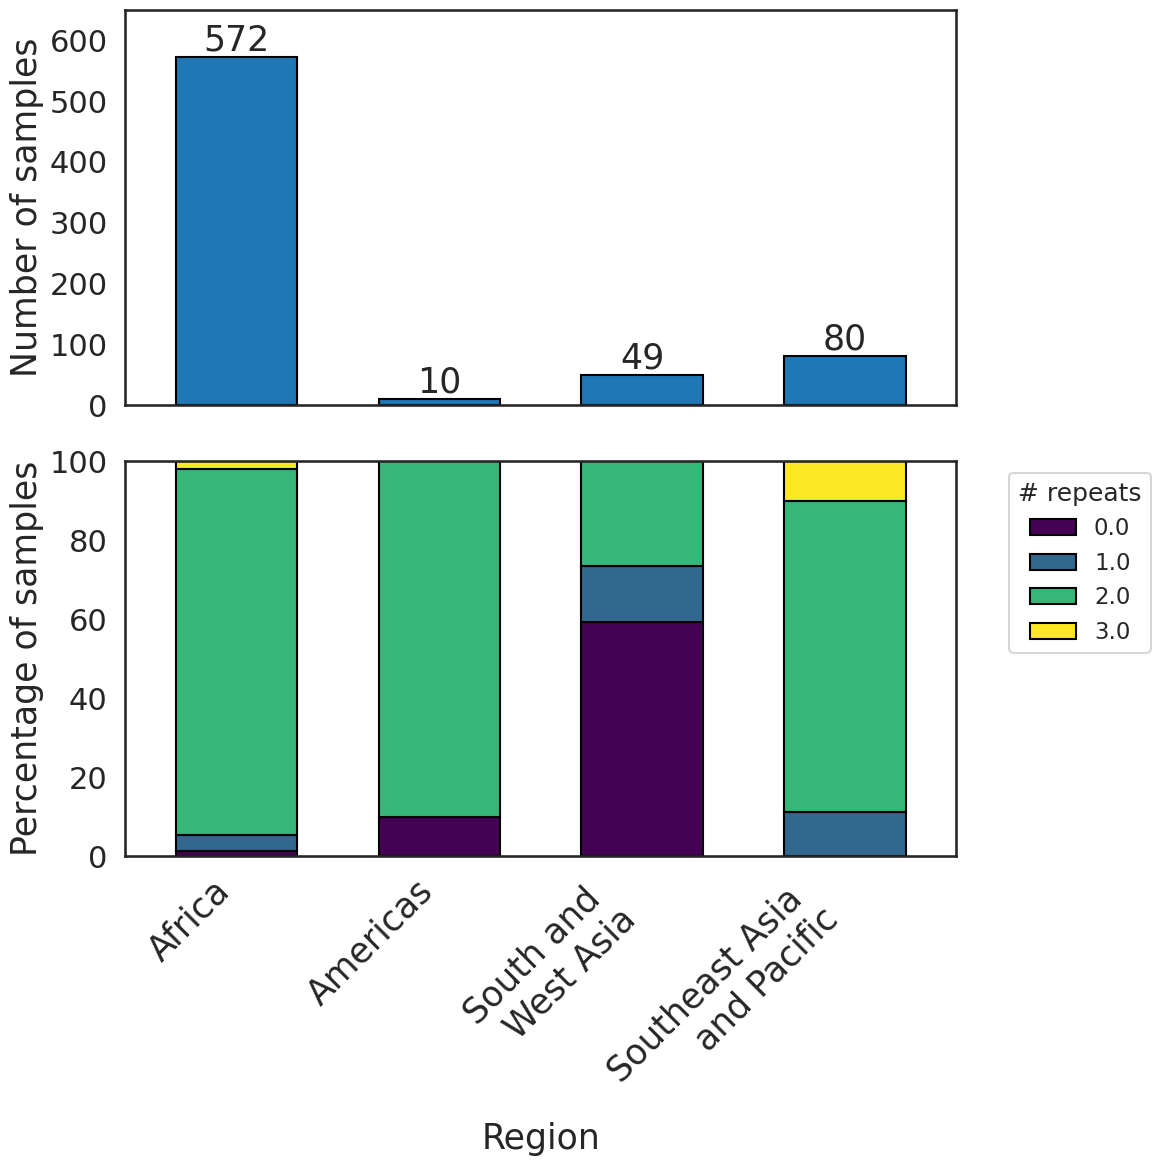


Percentage breakdown:
Num_4distance                   0.0    1.0    2.0   3.0
Region                                                 
Africa                         1.40   4.02  92.48   2.1
Americas                      10.00   0.00  90.00   0.0
South and \nWest Asia         59.18  14.29  26.53   0.0
Southeast Asia \nand Pacific   0.00  11.25  78.75  10.0


In [41]:
# Compute percentage breakdowns by number of repeats separated by 4 aa
# and make plots

# Plot 1

df = dat.replace('West Africa','Africa').replace('East Africa','Africa').replace('Central Africa','Africa').replace('West Asia','South and \nWest Asia').replace('South Asia','South and \nWest Asia').replace('Pacific','Southeast Asia \nand Pacific').replace('Southeast Asia','Southeast Asia \nand Pacific').replace('Southeast Asia and Pacific','Southeast Asia \nand Pacific').replace('Southeast Asia','Southeast Asia \nand Pacific').replace('South America','Americas')
df = df.groupby(["Region","Num_4distance"]).apply("count").reset_index()

# Calculate percentage breakdown for each region
df_pivot = df.pivot_table(
    index='Region',
    columns='Num_4distance',
    values='Sample',
    fill_value=0
)

# Calculate totals
df_pct = df_pivot.sum(axis=1)

# Create the stacked bar chart
f, axs = plt.subplots(2, 1, figsize=(12, 12), sharex=True)
axs[0] = plt.subplot(211)
p = axs[0].bar(df_pivot.index, df_pct, edgecolor='black', width=0.6,)

# Customize the chart
axs[0].set_xlabel('', fontsize=25)
axs[0].set_ylabel('Number of samples', fontsize=25)
axs[0].set_ylim(0, 650)
plt.tick_params('x', labelbottom=False)
axs[0].set_yticklabels(axs[0].get_yticklabels(), rotation=0, ha='right', fontsize=22, )
axs[0].bar_label(p, fontsize=25, )

print("\nTotals breakdown:")
print(df_pct.round(2))

# Calculate percentage breakdown for each region
df_pivot = df.pivot_table(
    index='Region',
    columns='Num_4distance',
    values='Sample',
    fill_value=0
)

df_pivot[4.0] = df_pivot.iloc[:, 3:].sum(axis=1)
    # sum all samples with four or more repeats at a distance of 4
df_pivot = df_pivot.drop(df_pivot.columns[[4]], axis=1)

# Calculate percentages
df_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100

# Create the stacked bar chart
axs[1] = plt.subplot(212)
df_pct.plot(kind='bar', stacked=True, ax=axs[1], colormap='viridis', edgecolor='black', width=0.6)

# Customize the chart
axs[1].set_xlabel('Region', fontsize=25)
axs[1].set_ylabel('Percentage of samples', fontsize=25, )
axs[1].legend(title='# repeats', bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1].set_ylim(0, 100)
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45, ha='right', fontsize=25, )
axs[1].set_yticklabels(axs[1].get_yticklabels(), rotation=0, ha='right', fontsize=22, )

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/stacked_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPercentage breakdown:")
print(df_pct.round(2))